In [ ]:
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.wcs import WCS
from astropy.time import Time
from astropy.table import join
from lsst.daf.butler import Butler
from lsst.afw.image import installGaussianPsf
from lsst.afw.geom import SpherePoint
from dataclasses import dataclass, field, asdict
import json
from glob import glob
import logging
import numpy as np
import re
from typing import List
from astropy.table import Table
import logging
import numpy as np
import scipy as sci
import torch
import gc
import time
from astropy.io import fits
from pathlib import Path
import gc
import logging
import numpy as np
from astropy.table import Table, vstack
from pathlib import Path
from torch.nn import functional
import torch

from __future__ import annotations

from ctypes import POINTER
import logging
from typing import Any, Mapping, Sequence

import numpy as np
from astropy.table import Table
from lsst.geom import Point2D  # type: ignore[import-untyped]
from lsst.afw.image import ImageOrigin
import lsst.meas.algorithms.installGaussianPsf as installGaussianPsf




def read_flag_list_from_file(flags_fn) -> [str]:
    """Read the list of flags to mask
    """
    flag_keys = []
    with open(flags_fn) as han:
        for line in han.readlines():
            if line.startswith('#'):
                continue
            key = line.split()[0]
            flag_keys.append(key)

    logging.debug(f"FLAG_KEYS: {flag_keys}")
    return flag_keys


@dataclass
class StackParams(object):
    params_filename: str  # filename to save parameters to
    badflags: List[str] = field(default_factory=list)  # bad flags
    dist_lim: float = 5.0  # candidate-line distance in clustering routine
    dist_lim_x: int = 4  # maximum cluster distance in x
    dist_lim_y: int = 6  # maximum cluster distance in y
    dist_max: float = 4.0  # maximum spatial sep planted/detected link
    dist_rate_max: float = 60.0  # maximum rate sep  for plan/detected link
    kernel_width: int = 14  # width of kernel in pixels
    min_samp: int = 3  # minimum number of clustered detections required
    min_snr: float = 4.5  # Minimum SNR for a detection
    n_keep: int = 10000  # number of sources to keep after initial serach
    peak_offset_max: float = 4  # max distance between peak and centre of stamp
    rate_fwhm_grid_step: float = 0.75  # width of steps in units of FWHM
    trim_snr: float = 5.5  # min SNR of sources to keep after clustering
    use_gaussian_kernel: bool = False  # use a guassian kernel instead of a PSF
    use_negative_well: bool = True  # use the negative well for detection.
    variance_trim: float = 1.3  # factor above median variance to mask pixels

    def save(self) -> None:
        logging.info(f"Saving params to {self.params_filename}")
        with open(self.params_filename, 'w+') as han:
            json.dump(asdict(self), han)

    def __iter__(self) -> dict:
        yield from asdict(self).items()

# this class creates the needed data for shift-and-stack using files that have already been extracted
# from the Butler.
class ExtractedDataModel(object):
    WCS_EXT = 1
    IMAGE_EXT = 1
    MASK_EXT = 2
    VARIANCE_EXT = 3
    MASK_PREFIX = "MP_"
    MAX_PIX_VALUE = 8000
    MIN_PIX_VALUE = -10000
    VARIANCE_BITMASK = "SAT"

    def __init__(self, base_dir, collections, day_obs, chip, dataset_type,
                 bitmask_filename=None, data_dtype=np.float32):
        self.base_dir = base_dir
        self.collections = collections
        self.day_obs = day_obs
        self.chip = chip
        self.dataset_type = dataset_type
        self.properties_dataset_type = "properties"
        self.bitmask_filename = bitmask_filename
        self.data_dtype = data_dtype
        self._warps = None
        self._psfs = None
        self._properties = None
        self._ref_wcs = None
        self._ref_visit = None
        self._ref_header = None
        self._bitmask = None
        self._plants = None
        self._stack_inputs = None

    # mask high, low, nan and inf pixels and
    # remove images that are fully masked
    def mask_variance(self, variance_trim) -> {'str': [np.array]}:
        """set the var_trim_keyword mask to ON if data exceeds variance_trim
        fraction of variance.

        Args:
            variance_trim (float): variance threshold fraction
            var_trim_keyword (str, optional): mask string. Default 'SAT'
        """
        datas = self.stack_inputs['datas']
        variances = self.stack_inputs['variances']
        masks = self.stack_inputs['masks']
        dmjds = self.stack_inputs['dmjds']
        im_nums = self.stack_inputs['im_nums']
        for idx in range(len(datas)):
            mask_bit = np.uint32(1) << np.uint32(self.bitmask[self.VARIANCE_BITMASK])
            w = np.where((np.isinf(variances[idx])) |
                         (np.isinf(datas[idx])) |
                         (np.isnan(datas[idx])) |
                         (datas[idx] > self.MAX_PIX_VALUE) |
                         (datas[idx] < self.MIN_PIX_VALUE))
            masks[idx][w] |= mask_bit
            variances[idx][w] = np.nan
            datas[idx][w] = 0.0
            nan_med_variance = np.nanmedian(variances[idx])
            logging.debug((f"{im_nums[idx]} {dmjds[idx]} {nan_med_variance}"))
            if np.isnan(nan_med_variance):
                logging.debug('Skipping image {im_nums[idx]} due to nans.')
                for key in self.stack_inputs:
                    _ = self._stack_inputs[key].pop(idx)
            else:
                w = np.where(
                    variances[idx] >
                    variance_trim*nan_med_variance)
                masks[idx][w] |= mask_bit

    def pack_inputs(self) -> None:
        """convert list of arrays in stack_inputs into 3d arrays

        """
        for key in ['datas', 'variances', 'psfs', 'dmjds', 'fwhms']:
            self.stack_inputs[key] = np.array(self.stack_inputs[key],
                                              dtype=self.data_dtype)
        self.stack_inputs['masks'] = np.array(self.stack_inputs['masks'],
                                              dtype=np.uint32)
        self.stack_inputs['im_nums'] = np.array(self.stack_inputs['im_nums'],
                                                dtype=np.int32)
        # im_nums should be int arrays
        # self.stack_inputs['im_nums'] = (
        #    self.stack_inputs['im_nums'].astype('int'))
        return self.stack_inputs

    @property
    def stack_inputs(self) -> {str: [np]}:
        """ pack data into a dictionary of numpy arrays
            for use in shift-and-stack code.
        """
        if self._stack_inputs is not None:
            return self._stack_inputs
        PSF_DATA_EXTNO = 0
        DATA_EXTNO = 1
        MASK_EXTNO = 2
        VARIANCE_EXTNO = 3
        datas, masks, variances = [], [], []
        dmjds, psfs, fwhms, im_nums = [], [], [], []
        logging.debug("Creating numpy data lists to pack data onto GPU with.")
        for im_num in self.warps:
            hdul = self.warps[im_num]
            datas.append(np.asarray(hdul[DATA_EXTNO].data,
                                    dtype=self.data_dtype))
            masks.append(np.asarray(hdul[MASK_EXTNO].data, dtype=np.uint32))
            variances.append(np.asarray(hdul[VARIANCE_EXTNO].data,
                                        dtype=self.data_dtype))
            dmjds.append(self.properties[im_num]['dmjd'])
            fwhms.append(self.properties[im_num]['fwhm'])
            psf_data = np.asarray(self.psfs[im_num][PSF_DATA_EXTNO].data,
                                  dtype=self.data_dtype)
            psfs.append(psf_data/np.sum(psf_data))
            im_nums.append(im_num)
        logging.debug(f"Using {len(datas)} images.")
        self._stack_inputs = {
            'datas': datas,
            'masks': masks,
            'variances': variances,
            'dmjds': dmjds,
            'psfs': psfs,
            'fwhms': fwhms,
            'im_nums': im_nums,
            'plants': self.plants,
            'bitmask': self.bitmask}
        return self.stack_inputs

    @property
    def path(self):
        return "/".join([self.base_dir,
                         self.collections,
                         self.day_obs,
                         self.chip])

    @property
    def filename_pattern(self) -> str:
        return f"{self.path}/{self.dataset_type}_??????_{self.chip}"

    def visit_number_from_filename(self, filename) -> int:
        visit_re = re.compile('_([0-9]{6})_')
        return int(visit_re.search(filename).group(1))

    @property
    def bitmask(self) -> {}:
        if self._bitmask is not None:
            return self._bitmask
        if self.bitmask_filename is not None:
            logging.debug("LOADNIG BITMASK FROM {self.bitmask_filename}")
            with open(self.bitmask_filename) as han:
                self._bitmask = {}
                for line in han.readlines():
                    if line.startswith('#'):
                        continue
                    s = line.split(': ')
                    key, val = s[0], int(float(s[1]))
                    self._bitmask[key] = val
            logging.debug(f"FILE BITMASK: {self._bitmask}")
        else:
            logging.debug(f"LOADING BITMASK FROM {self.ref_visit} HEADER")
            header = self.warps[self.ref_visit][self.MASK_EXT].header
            # get all keywords that start with MASK_PREFIX and then
            # strip the prefix from keyword to map to common usage
            # e.g. MP_BAD => BAD
            bitmask = header[f"{self.MASK_PREFIX}*"]
            self._bitmask = {x.removeprefix(self.MASK_PREFIX): bitmask[x]
                             for x in bitmask}
            logging.debug(f"HEADER BITMASK: {self._bitmask}")
        return self._bitmask

    @property
    def properties(self) -> {}:
        """Load the image propertes (mjd, fwhm, exposuer_time) from storage
        """
        if self._properties is not None:
            return self._properties
        prop_filename = (f"{self.path}/"
                         f"{self.properties_dataset_type}_{self.chip}.txt")
        logging.debug(f"Loading properties from {prop_filename}")
        table = Table.read(prop_filename, format='ascii.commented_header')
        # compute delta mjd as the time since the first exposure plus
        # 1/2 exposure time.
        mjd0 = table[table['visit'] == self.ref_visit]['mjd'][0]
        table['dmjd'] = table['mjd'] - mjd0
        table['dmjd'] += table['exposure_time']/2.0/3600/24.0
        properties = {}
        for visit in set(table['visit']):
            w = table['visit'] == visit
            row = table[w][0]
            properties[visit] = row['dmjd', 'fwhm']
        logging.debug(f"Loaded {len(properties)} property records")
        self._properties = properties
        return self._properties

    @property
    def psfs(self):
        """load the psfs from storage"""
        if self._psfs is not None:
            return self._psfs
        filelist = glob(self.filename_pattern+".psf.fits")
        filelist.sort()
        self._psfs = {self.visit_number_from_filename(x): fits.open(x)
                      for x in filelist}
        logging.info(f"Loaded {len(self._psfs)} psfs")
        return self._psfs

    @property
    def ref_header(self):
        if self._ref_header is None:
            self._ref_header = self.warps[self.ref_visit][self.WCS_EXT].header
        return self._ref_header

    @property
    def ref_wcs(self):
        """Get the WCS of the reference visit"""
        if self._ref_wcs is None:
            self._ref_wcs = WCS(self.ref_header)
        return self._ref_wcs

    @property
    def ref_visit(self):
        """The visit number of the reference visit,
        in this case the key of the first
        entry in the warps dictionary"""
        if self._ref_visit is None:
            self._ref_visit = next(iter(self.warps.keys()))
        return self._ref_visit

    @property
    def warps(self):
        """load warped diffs from storage"""
        if self._warps is not None:
            return self._warps
        filelist = glob(self.filename_pattern+".fits")
        filelist.sort()
        self._warps = {self.visit_number_from_filename(x): fits.open(x)
                       for x in filelist}
        logging.info(f"Loaded {len(self._warps)} warped difference images")
        return self._warps

    @property
    def plants(self) -> Table:
        """Load a list of sources injected into the reference image.
        x0: x pixel location on first image
        y0: y pixel locaiton on first image
        rate_x: rate of motion in x direction in pixels/hour
        rate_y: rate of motion in y direction in pixels/hour
        mag: the magnitude of planted soruce.
        4 blank columns, expected to hold the information from the
            detection process:
                det_shift, det_filt, det_clust, det_final, num_match
        """
        if self._plants is not None:
            return self._plants
        plants_list = []
        path = "/".join([self.base_dir,
                         self.collections,
                         self.day_obs,
                         "*"])
        plant_pattern = "_".join([self.dataset_type,
                                  str(self.ref_visit),
                                  "*"])
        plant_pattern = f"{path}/{plant_pattern}.plantList"
        for plant_filename in glob(plant_pattern):
            plants = Table.read(plant_filename, format='ascii.commented_header')
            x0, y0 = self.ref_wcs.all_world2pix(plants['ra'], plants['dec'], 0)
            plants['x0'] = x0
            plants['y0'] = y0
            ra1 = plants['ra'] + plants['rate_ra']/3600.0
            dec1 = plants['dec'] + plants['rate_dec']/3600.0
            x1, y1 = self.ref_wcs.all_world2pix(ra1, dec1, 0)
            plants['rate_x'] = (x1-x0)*24.0
            plants['rate_y'] = (y1-y0)*24.0
            plants.sort('mag')
            plants_list.append(plants)
        self._plants = vstack(plants_list)
        self._plants.sort('mag')
        return self._plants


In [ ]:


NOMINAL_PIXEL_SCALE = 0.17  # arcsec/pixel
MAX_SHIFT_RATE = 4.5  # arcsec/hour
MAX_RATE_PIX_PER_DAY = 24*MAX_SHIFT_RATE/NOMINAL_PIXEL_SCALE


def get_device() -> torch.device:
    """Determine if a GPU available and select as torch device.

    Returns:
        torch.device: The device that torch will use for processing.
    """
    gpu_available = torch.cuda.is_available()
    message = "Using GPU" if gpu_available else "No GPU. Using CPU"
    logging.info(message)
    return torch.device("cuda:0" if gpu_available else "cpu")


def get_shift_rates(plants: Table,
                    fwhms: np.array,
                    dmjds: np.array,
                    rate_fwhm_grid_step: float):
    """
    get a grid of shift rates from the plant list
    """
    # rotation hack because the chip 24 rates are
    # all positive in x not negative
    swap_signs = False
    if np.sum(plants['rate_x'] > 0) == len(plants):
        plants['rate_x'] *= -1.
        plants['rate_y'] *= -1.
        swap_signs = True

    logging.debug(f'Number of planted sources: {len(plants)}')
    w = (plants['rate_x']**2 + plants['rate_y']**2) < MAX_RATE_PIX_PER_DAY**2
    angs = np.arctan2(plants['rate_y'][w],
                      plants['rate_x'][w]) % (2*np.pi)

    min_ang = np.min(angs)
    max_ang = np.max(angs)
    med_ang = np.median(angs)
    # bodge angle hack
    if min_ang < 0:
        while min_ang < 0:
            min_ang += 2*np.pi
            med_ang += 2*np.pi

    d_ang = max(max_ang-med_ang, med_ang-min_ang)
    max_ang = med_ang + d_ang
    min_ang = med_ang - d_ang
    logging.debug((f"Angles (min:{min_ang}, max: {max_ang}, "
                   f"med: {med_ang}, delta: {d_ang})"))

    W = np.abs(plants['rate_x']) < 200
    line = sci.stats.linregress(plants['rate_x'][W],
                                plants['rate_y'][W])

    max_x = np.max(plants['rate_x'] + 5)
    max_y = max_x*line.slope + line.intercept

    logging.debug(f"Max x/y: {max_x}, {max_y}")

    seeing = np.mean(fwhms)*NOMINAL_PIXEL_SCALE  # 0.7
    logging.debug(f'Mean FWHM {seeing}" ')
    seeing /= NOMINAL_PIXEL_SCALE  # pixels

    # dh = (mjds[-1]-mjds[0]) # days
    # days, need to take the np.max and np.min because
    # images aren't necessarily in order of increase time.
    dh = np.max(dmjds)
    drate = rate_fwhm_grid_step*seeing/dh  # 0.75 seems to be a good sweet spot
    ang_steps_h = np.linspace(med_ang, max_ang+0.0, 80)
    ang_steps_l = np.linspace(min_ang-0.0, med_ang, 80)

    rates = [[max_x, max_y]]
    current_rate = (max_x**2+max_y**2)**0.5
    while current_rate < MAX_RATE_PIX_PER_DAY:
        n_x = np.cos(ang_steps_h)*current_rate  # + max_x
        n_y = np.sin(ang_steps_h)*current_rate  # + max_y

        dist_rates = (((n_x - n_x[0])**2 + (n_y - n_y[0])**2)**0.5) / drate
        dist_rates = dist_rates.astype('int')
        unique_dist_rates = np.unique(dist_rates)
        for ind in unique_dist_rates:
            w = np.where(dist_rates == ind)
            rates.append([n_x[w[0][0]], n_y[w[0][0]]])

        n_x = np.cos(ang_steps_l[::-1]) * current_rate  # + max_x
        n_y = np.sin(ang_steps_l[::-1]) * current_rate  # + max_y
        dist_rates = (((n_x - n_x[0])**2 + (n_y - n_y[0])**2)**0.5) / drate
        dist_rates = dist_rates.astype('int')
        unique_dist_rates = np.unique(dist_rates)
        for ind in unique_dist_rates.astype('int'):
            if ind == 0:
                continue
            w = np.where(dist_rates == ind)
            rates.append([n_x[w[0][0]], n_y[w[0][0]]])

        current_rate += drate
    # the first rate is duplicated in the above algorithm
    rates = np.array(rates)[1:]
    logging.debug(f"Number of rates: {len(rates)}")

    if swap_signs:
        rates *= -1.
        plants['rate_x'] *= -1.
        plants['rate_y'] *= -1.

    return rates


def create_kernel(psfs, dmjds,
                  rates=None,
                  useNegativeWell=True,
                  useGaussianKernel=False,
                  kernel_width=14,
                  im_nums=None,
                  dtype=np.float32):
    
    if psfs is None and not useGaussianKernel:
        logging.error("Set useGaussianKernal when no psfs provided")
        raise ValueError("Set useGaussianKernal when no psfs provided")
    mean_rate = np.mean(rates, axis=0, dtype=dtype)
    logging.debug(f"Creating kernel for rates: {mean_rate}")
    device = get_device()
    if useGaussianKernel:
        logging.debug("Using a Gaussian Kernel")
        # kernel_width = 10
        std = 1.5
        khw = kernel_width//2
        (x, y) = np.meshgrid(np.arange(kernel_width),
                             np.arange(kernel_width))
        gauss = np.exp(-((x-khw-0.5)**2 + (y-khw-0.5)**2)/(2*std*std), 
                       dtype=dtype)
        gauss /= np.sum(gauss, dtype=dtype)

        kernel = torch.tensor(
            np.zeros((1, 1, len(dmjds), kernel_width, kernel_width),
                     dtype=dtype)
            ).to(device)  # .cuda()
        for ir in range(len(dmjds)):
            kernel[0, 0, ir, :, :] = torch.tensor(np.copy(gauss))

    else:
        logging.debug('Using PSF kernel')
        # kernel_width = 1000
        # for i in range(len(psfs)):
        #    kernel_width = min(kernel_width, psfs[i].shape[0])
        # khw = kernel_width//2
        # using kernel widths between 10 and 30 doesn't
        # produce much different outputs in terms of depth
        # kernel_width = 14
        khw = kernel_width//2

        kernel = torch.tensor(
            np.zeros((1, 1, len(psfs), kernel_width, kernel_width),
                     dtype=dtype)
            ).to(device)
        for ir in range(len(psfs)):
            psf = psfs[ir]
            (a, b) = psf.shape
            delt = (a-kernel_width)//2

            psf_section = psf[delt:delt+kernel_width, delt:delt+kernel_width]
            psf_section /= np.sum(psf_section)

            kernel[0, 0, ir, :, :] = torch.tensor(np.copy(psf_section))

    if useNegativeWell:
        mean_kernel = torch.sum(kernel[0, 0], 0)
        mean_kernel /= torch.sum(mean_kernel)

        c = torch.zeros_like(kernel)
        mid_im = len(psfs)//2
        DMJDS = dmjds-dmjds[mid_im]

        for id in range(0, len(psfs)):
            shifts = (int(-np.round(DMJDS[id]*mean_rate[1])),
                      int(-np.round(DMJDS[id]*mean_rate[0])))
            logging.debug(f"shifts for negative wells: {shifts}")
            if (abs(shifts[0]) < khw) & (abs(shifts[1]) < khw):
                c[0, 0, id,] = torch.roll(mean_kernel,
                                          shifts=shifts,
                                          dims=[0, 1])
        trail = torch.sum(c[0, 0], 0)
        trail /= torch.sum(trail)*3.

        for id in range(len(psfs)):
            kernel[0, 0, id] -= trail

    return kernel


In [ ]:

def run_shifts(datas, inv_variances, rates, dmjds, min_snr, n_keep=4,
               writeTestImages=False, tile_w=256,
               word_dtype=torch.float16):
    n_im = len(datas[0, 0, :])
    logging.debug(f'NUM IM {n_im}')
    c = torch.zeros_like(datas)
    c[0, 0, 0] = datas[0, 0, 0]
    cv = torch.zeros_like(datas)
    cv[0, 0, 0] = inv_variances[0, 0, 0]

    snr_image = torch.zeros((1, 1,
                             len(rates), datas.size()[3], datas.size()[4]),
                            dtype=word_dtype)
    alpha_image = torch.zeros((1, 1,
                              len(rates), datas.size()[3], datas.size()[4]),
                              dtype=word_dtype)

    # rates=[[-200.6777606841237, 78.88276756451387]]
    for ir in range(len(rates)):
        for idx in range(1, n_im):
            shifts = (-round(dmjds[idx]*rates[ir][1]),
                      -round(dmjds[idx]*rates[ir][0]))
            c[0, 0, idx,] = torch.roll(datas[0, 0, idx],
                                       shifts=shifts, dims=[0, 1])
            cv[0, 0, idx] = torch.roll(inv_variances[0, 0, idx],
                                       shifts=shifts, dims=[0, 1])
        # C = functional.conv3d(c, kernel)
        # sums = torch.sum(functional.conv3d(c, ones,padding='same'), 2)

        # these are set abov
        PSI = c
        PHI = cv

        # median_alpha = torch.median(PSI/PHI, dim=2)[0]
        # doesn't seem to be used for anything

        alpha = torch.nansum(PSI/PHI, 2)  # flux estimate
        alpha = torch.nan_to_num(alpha, 0.0)

        # SNR estimate
        nu = torch.sum(PSI, 2)/torch.pow(torch.sum(PHI, 2), 0.5)
        nu = torch.nan_to_num(nu, -1.0)

        # check to see if making all snr==inf go to zero fixes the
        # infinities error you are getting
        nu[nu == float("Inf")] = 0
        #

        where = nu[0, 0] > min_snr
        inds = where.nonzero()

        snr_image[0, 0, ir, inds[:, 0], inds[:, 1]] = (
            nu[0, 0, inds[:, 0], inds[:, 1]].cpu().to(word_dtype))
        # flux per image not per stack
        alpha_image[0, 0, ir, inds[:, 0], inds[:, 1]] = (
            alpha[0, 0, inds[:, 0], inds[:, 1]].cpu()/n_im)

        gc.collect()
        torch.cuda.empty_cache()

    logging.info(f'Max per image flux of candidates: {torch.max(alpha_image)}')
    logging.info(f'Max per image snr of candidates: {torch.max(snr_image)}')

    del c, cv, datas, inv_variances, PSI, PHI
    gc.collect()
    torch.cuda.empty_cache()

    return snr_image, alpha_image


def trim_negative_snr(snr_image, alpha_image, sort_inds,
                      n_keep, A, B, dtype=np.float16):
    # trim the negative SNR sources. The reason these show up is
    # because the likelihood formalism sucks
    idx, idy = np.meshgrid(np.arange(B), np.arange(A))
    idx = idx.reshape(A*B)
    idy = idy.reshape(A*B)
    for n in range(n_keep):
        s = sort_inds[0, 0, n, :, :].reshape(A*B)
        SNR = snr_image[0, 0, s, idy, idx]
        alpha = alpha_image[0, 0, s, idy, idx]

        where = SNR > 0
        inds = where.nonzero()[:, 0]
        logging.debug(f"keep index length: {inds.shape}")
        logging.debug(f"length of indexs: {(s[inds]).shape}")
        if n == 0:
            keeps = np.zeros((len(inds), 7), dtype=dtype)
            keeps[:, 0] = idx[inds]
            keeps[:, 1] = idy[inds]
            keeps[:, 2] = s.reshape(A*B)[inds]
            keeps[:, 3] = 0.0
            keeps[:, 4] = alpha.reshape(A*B)[inds]
            keeps[:, 5] = SNR.reshape(A*B)[inds]
        else:
            nkeeps = np.zeros((len(inds), 7), dtype=dtype)
            logging.debug(f"Keeps size: {nkeeps.shape}")
            nkeeps[:, 0] = idx[inds]
            nkeeps[:, 1] = idy[inds]
            nkeeps[:, 2] = s[inds]
            nkeeps[:, 3] = 0.0
            nkeeps[:, 4] = alpha.reshape(A*B)[inds]
            nkeeps[:, 5] = SNR.reshape(A*B)[inds]
            keeps = np.concatenate([keeps, nkeeps])

    logging.info(f'Keeping {len(keeps)} candidates')

    detections = np.array(keeps)
    del keeps, idx, idy
    return detections


def trim_negative_flux(detections):
    pos = np.where(detections[:, 4] > 0)
    detections = detections[pos]
    logging.info(f'Keeping {len(detections)} positive flux candidates')
    return detections


def brightness_filter(im_datas, inv_vars, c, cv, kernel,
                      dmjds, rates, detections, khw, n_im,
                      n_bright_test=10, test_high=1.15, test_low=0.85):

    device = get_device()
    nb_ref = torch.as_tensor(10.0**np.linspace(np.log10(test_low),
                                               np.log10(test_high),
                                               n_bright_test),
                             dtype=im_datas.dtype,
                             device=device)

    for ir in range(len(rates)):
        t1 = time.time()
        w = np.where((detections[:, 2] == rates[ir][0]) &
                     (detections[:, 3] == rates[ir][1]))

        for idx in range(1, n_im):
            shifts = (-round(dmjds[idx]*rates[ir][1]),
                      -round(dmjds[idx]*rates[ir][0]))
            c[0, 0, idx] = torch.roll(im_datas[0, 0, idx],
                                     shifts=shifts, dims=[0, 1])
            cv[0, 0, idx] = torch.roll(inv_vars[0, 0, idx],
                                      shifts=shifts, dims=[0, 1])

        arg_mins = torch.zeros(len(detections), dtype=torch.uint32)
        for idx in w[0]:
            (x, y) = detections[idx, :2]
            x = int(x) + khw
            # array of scaled brightnesses in steps of brightness*test_low
            # to brightness*test_high
            y = int(y) + khw
            nb = nb_ref*detections[idx, 4]
            k = kernel.repeat((1, n_bright_test, 1, 1, 1))
            for ib in range(nb.size()[0]):
                k[:, ib, :, :, :] *= nb[ib]

            diff = c[:, :, :, y-khw:y+khw, x-khw:x+khw].repeat(
                (1, n_bright_test, 1, 1, 1))
            diff -= k
            diff = diff*diff
            diff *= cv[:, :, :, y-khw:y+khw, x-khw:x+khw].repeat(
                (1, n_bright_test, 1, 1, 1))

            tmp = torch.sum(diff, (0, 2, 3, 4))
            arg_mins[idx] = torch.argmin(tmp)

        arg_mins_cpu = arg_mins.cpu()

        W = np.where((arg_mins_cpu != 0) & (arg_mins_cpu != (n_bright_test-1)))
        logging.debug((f'{ir+1}/{len(rates)}, pre: {len(w[0])}, '
                       f'post: {len(W[0])},  in time {time.time()-t1}'))
        if ir == 0:
            keeps = W[0]
        else:
            keeps = np.concatenate([keeps, W[0]])
    logging.info((f'Number kept after brightness filter {len(keeps)}'
                  f' of {len(detections)} total detections.'))

    return keeps


def create_stamps(im_datas, im_masks, c, cv, dmjds, rates,
                  filt_detections, khw):
    mean_stamps = []
    indices = []
    # saved = False
    for ir in range(len(rates)):

        # these are required to reset from the nans below
        c[0, 0, 0] = im_datas[0, 0, 0]
        cv[0, 0, 0] = im_masks[0, 0, 0]

        # t1 = time.time()
        w = np.where(np.round(filt_detections[:, 2]).astype("int") == ir)

        for idx in range(1, len(dmjds)):
            shifts = (-round(dmjds[idx]*rates[ir][1]),
                      -round(dmjds[idx]*rates[ir][0]))
            c[0, 0, idx] = torch.roll(im_datas[0, 0, idx],
                                     shifts=shifts, dims=[0, 1])
            # mask values with 1 are GOOD pixels
            cv[0, 0, idx] = torch.roll(im_masks[0, 0, idx],
                                      shifts=shifts, dims=[0, 1])
        mean_stamp_frame = torch.sum(c, 2)

        mask_frame = torch.sum(cv, 2)

        for iw in w[0]:
            x, y = filt_detections[iw, :2].astype('int')
            mean_stamp = mean_stamp_frame[0, 0, y:y+khw*2+1, x:x+khw*2+1]

            """
            med_sections = c[0,0,:,y:y+khw*2+1, x:x+khw*2+1].cpu()
            mask_sections = cv[0,0,:,y:y+khw*2+1, x:x+khw*2+1].cpu()
            mask_sections[np.where((np.isnan(mask_sections)) |
                                   (np.isinf(mask_sections)))] = 0

            # mask_sections==0 are bad pixels
            # numpy masks value == 1 are bad pixels
            masked_med_sections = ma.array(med_sections, mask= 1-mask_sections)
            med_stamps.append(ma.median(masked_med_sections,axis=0).filled(0.0))
            """

            mask = np.copy(mask_frame[0, 0, y:y+khw*2+1, x:x+khw*2+1].cpu())
            mask[np.where((np.isnan(mask)) | (np.isinf(mask)))] = 0.0
            np.clip(mask, 1., len(dmjds), out=mask)
            mean_stamps.append(np.copy(mean_stamp.cpu())/mask)

            indices.append(iw)

    indices = np.array(indices)
    mean_stamps = np.array(mean_stamps)[indices]

    del mask, mean_stamp, mean_stamp_frame, mask_frame
    gc.collect()
    torch.cuda.empty_cache()

    return mean_stamps


# trim the ones with peak offset more than peak_offset_max pixels
def peak_offset_filter(stamps, filt_detections, peak_offset_max):
    (N, a, b) = stamps.shape
    (gx, gy) = np.meshgrid(np.arange(b), np.arange(a))
    gx = gx.reshape(a*b)
    gy = gy.reshape(a*b)
    rs_stamps = stamps.reshape(N, a*b)
    args = np.argmax(rs_stamps, axis=1)
    X = gx[args]
    Y = gy[args]
    radial_d = ((X-b/2)**2+(Y-a/2)**2)**0.5
    w = np.where(radial_d < peak_offset_max)
    filt_detections = filt_detections[w]
    stamps = stamps[w]

    return stamps, filt_detections


# do predictive line clustering
def predictive_line_cluster(filt_detections, stamps, dmjds, dist_lim,
                            min_samp=2, init_select_proc_distance=60):

    proc_filt_detections = np.copy(filt_detections)

    proc_inds = np.arange(len(proc_filt_detections))
    clust_detections, clust_inds = [], []

    while len(proc_filt_detections) > 0:

        arg_max = np.argmax(proc_filt_detections[:, 5])  # 5 - max on SNR
        x_o, y_o, rx_o, ry_o, f_o, snr_o = proc_filt_detections[arg_max, :6]

        # this secondary where command is necessary because of memory
        # overflows in large detection lists
        w = np.where((proc_filt_detections[:, 0] >
                      proc_filt_detections[arg_max, 0]-55)
                     & (proc_filt_detections[:, 0] <
                        proc_filt_detections[arg_max, 0] +
                        init_select_proc_distance)
                     & (proc_filt_detections[:, 1] >
                        proc_filt_detections[arg_max, 1]-55)
                     & (proc_filt_detections[:, 1] <
                        proc_filt_detections[arg_max, 1] +
                        init_select_proc_distance))

        W = np.where(((proc_filt_detections[w[0], 0] -
                       proc_filt_detections[arg_max, 0])**2 + (
                           proc_filt_detections[w[0], 1] -
                           proc_filt_detections[arg_max, 1])**2) <
                     init_select_proc_distance**2)
        w = w[0][W[0]]

        fd_subset = proc_filt_detections[w]

        drx = fd_subset[:, 2] - rx_o
        dry = fd_subset[:, 3] - ry_o
        dt = dmjds  # just for clarity

        # predicted centroid  position of secondary detection shifted at the
        # differential wrong rate.
        x_n, y_n = x_o - drx*dt[-1], y_o - dry*dt[-1]
        # predicted centroid shifted such that best detection is now at origin
        dx, dy = (x_n - x_o), (y_n - y_o)

        dxp = dx*fd_subset[:, 1]
        dyp = dy*fd_subset[:, 0]
        xm = x_n*y_o
        ym = y_n*x_o
        dx2 = dx**2
        dy2 = dy**2
        top = np.abs(dyp - dxp + xm - ym)
        bottom = np.sqrt(dx2 + dy2)
        dist = top/bottom

        clust = np.where((dist < dist_lim) |
                         (np.isnan(dist)) |
                         ((dist < dist_lim) &
                          (drx == 0) & (dry == 0)))
        if len(clust[0]) >= min_samp:
            clust_detections.append(proc_filt_detections[arg_max])
            clust_inds.append(proc_inds[arg_max])

        mask = np.ones(len(proc_filt_detections), dtype='bool')
        mask[w[clust]] = False
        proc_filt_detections = proc_filt_detections[mask]
        proc_inds = proc_inds[mask]

    clust_detections = np.array(clust_detections)
    clust_stamps = stamps[np.array(clust_inds)]

    return clust_detections, clust_stamps


def position_filter(clust_detections, clust_stamps, im_datas,
                    inv_vars, c, cv, kernel,
                    dmjds, rates, khw, n_offsets=5,
                    debug_detection_indices=None,
                    debug_output_dir=None):

    # now apply a positional filter on the clust_detections to see
    # if the likelihood minimimum is near the centre
    # n_offsets = 5 # +- n_offsets in x and y
    n_o = n_offsets*2+1
    # copy the tensor data in kernel to k with extra space for offsets
    k = kernel.repeat((1, n_o*n_o, 1, 1, 1))

    danger_edges = []
    # these are the indices of the maximal offsets in x and y
    for iy in range(n_o):
        for ix in range(n_o):
            i = iy*n_o+ix
            shifts = (0, iy-n_offsets, ix-n_offsets)
            # roll the kernel data by offset amounts and place
            # into offset kernel tensor.  This moves centre of the
            # kernel over a grid of size n_o x n_o positions
            k[0, i, :, :, :] = torch.roll(kernel[0, 0],
                                          shifts=shifts,
                                          dims=[0, 1, 2])
            if iy == 0 or iy == n_o-1 or ix == 0 or ix == n_o-1:
                # if the best offset pushes to the edget then 
                # this likely indicates the sources is not a real
                # moving source but noise that is coherent at the shift rate
                danger_edges.append(i)

    # cv will hold the variances which will be rolled along with
    # the image data which is in 'c'
    cv[0, 0, 0] = inv_vars[0, 0, 0]
    c[0, 0, 0] = im_datas[0, 0, 0]

    write_debug = (logging.getLogger().isEnabledFor(logging.DEBUG) and
                   debug_detection_indices is not None and
                   debug_output_dir is not None)
    debug_indices = set()
    debug_dir = None
    if write_debug:
        debug_indices = set(np.asarray(debug_detection_indices, dtype=int))
        debug_dir = Path(debug_output_dir)
        debug_dir.mkdir(parents=True, exist_ok=True)

    keeps = []
    for ir in range(len(rates)):
        w = np.where(np.round(clust_detections[:, 2]).astype("int") == ir)
        if len(w[0]) == 0:
            continue

        for idx in range(1, len(dmjds)):
            shifts = (-round(dmjds[idx]*rates[ir][1]),
                      -round(dmjds[idx]*rates[ir][0]))
            c[0, 0, idx] = torch.roll(im_datas[0, 0, idx],
                                      shifts=shifts,
                                      dims=[0, 1])
            cv[0, 0, idx] = torch.roll(inv_vars[0, 0, idx],
                                       shifts=shifts,
                                       dims=[0, 1])

        for idx in w[0]:

            (x, y) = clust_detections[idx, :2]
            x = int(x)  # +khw
            y = int(y)  # +khw

            K = k*clust_detections[idx, 4]
            c_patch = c[:, :, :, y:y+khw*2, x:x+khw*2]
            cv_patch = cv[:, :, :, y:y+khw*2, x:x+khw*2]

            diff = c_patch.repeat(
                (1, n_o*n_o, 1, 1, 1))
            diff -= K
            diff = diff**2
            diff *= cv_patch.repeat(
                (1, n_o*n_o, 1, 1, 1))
            arg_min = torch.argmin(torch.sum(diff, (0, 2, 3, 4)))
            min_ix = arg_min % n_o
            min_iy = int((arg_min-min_ix)/n_o)

            min_ix -= n_offsets
            min_iy -= n_offsets
            logging.debug((f"position 'Xi^2' match for sources at {x},{y} at rate:"
                           f"{rates[ir]} is offset {min_ix},{min_iy}"))
            kept = arg_min not in danger_edges
            if kept:
                keeps.append(idx)
            if write_debug and idx in debug_indices:
                primary = fits.PrimaryHDU()
                primary.header['DETIDX'] = int(idx)
                primary.header['RATEIDX'] = int(ir)
                primary.header['X'] = float(clust_detections[idx, 0])
                primary.header['Y'] = float(clust_detections[idx, 1])
                primary.header['FLUX'] = float(clust_detections[idx, 4])
                primary.header['SNR'] = float(clust_detections[idx, 5])
                primary.header['ARGMIN'] = int(arg_min)
                primary.header['MINIX'] = int(min_ix)
                primary.header['MINIY'] = int(min_iy)
                primary.header['KEPT'] = int(kept)
                hdus = [primary,
                        fits.ImageHDU(
                            np.asarray(c_patch.detach().cpu().squeeze(0).squeeze(0),
                                       dtype=np.float32),
                            name='C'),
                        fits.ImageHDU(
                            np.asarray(cv_patch.detach().cpu().squeeze(0).squeeze(0),
                                       dtype=np.float32),
                            name='CV'),
                        fits.ImageHDU(
                            np.asarray(diff.detach().cpu().squeeze(0),
                                       dtype=np.float32),
                            name='DIFF')]
                dump_path = debug_dir / f'position_filter_det_{int(idx):05d}.fits'
                fits.HDUList(hdus).writeto(dump_path, overwrite=True)
                logging.debug("Wrote position_filter debug cubes to %s",
                              dump_path)

    keeps = np.array(keeps)
    grid_detections = clust_detections[keeps]
    grid_stamps = clust_stamps[keeps]
    logging.debug(f"First grid {grid_detections[0]}")
    logging.debug(f"First cluster detection {clust_detections[0]}")
    logging.info(('Number of sources kept after the cluster '
                  f'filtering: {len(clust_detections)}.'))

    logging.info(('Number of sources kept after the positional '
                  f'grid minimum search: {len(grid_detections)}.'))

    return grid_detections, grid_stamps


def brightness_filter_fast(im_datas, inv_vars, c, cv, kernel,
                           dmjds, rates, detections, khw, n_im,
                           n_bright_test=10, test_high=1.15,
                           test_low=0.85,
                           n_det_iter=200,
                           word_dtype=torch.float16):

    device = get_device()

    nb_ref = torch.as_tensor(10.0**np.linspace(np.log10(test_low),
                                               np.log10(test_high),
                                               n_bright_test),
                             dtype=word_dtype,
                             device=device)

    ks = 2 * khw  # kernel spatial size
    # Precompute the unit-scaled kernel: shape (n_bright_test, n_im, ks, ks)
    # k_unit[ib] = kernel * nb_ref[ib]
    kern = kernel[0, 0]  # (n_im, ks, ks)
    # Wes added None and None to the front of each index selection
    # (n_bright_test, n_im, ks, ks)
    k_unit = kern[None, None, :, :, :] * nb_ref[None, :, None, None, None]

    # Precompute patch offset indices (reused every rate iteration)
    dy = torch.arange(ks, device=device)
    dx = torch.arange(ks, device=device)
    im_idx = torch.arange(n_im, device=device)

    keeps_list = []
    log_info_enabled = logging.getLogger().isEnabledFor(logging.INFO)

    for ir in range(len(rates)):
        t1 = time.time()
        W = np.where(np.round(detections[:, 2]).astype("int") == ir)

        if len(W[0]) == 0:
            continue

        # Roll images for this rate
        for idx in range(1, n_im):
            shifts = (-round(dmjds[idx]*rates[ir][1]),
                      -round(dmjds[idx]*rates[ir][0]))
            c[0, 0, idx] = torch.roll(im_datas[0, 0, idx],
                                     shifts=shifts,
                                     dims=[0, 1])
            cv[0, 0, idx] = torch.roll(inv_vars[0, 0, idx],
                                      shifts=shifts,
                                      dims=[0, 1])

        kept_chunks = []
        n_done_iter = 0
        while n_done_iter < len(W[0]):

            w = W[0][n_done_iter:min(n_done_iter+n_det_iter, len(W[0]))]

            det_idx = w
            n_det = len(det_idx)
            if n_det == 0:
                continue

            # Extract coordinates for all detections at this rate
            xs = detections[det_idx, 0].astype(int) + khw
            ys = detections[det_idx, 1].astype(int) + khw
            fluxes = torch.as_tensor(
                detections[det_idx, 4],
                dtype=word_dtype,
                device=device
            )

            # Batch-extract all patches via advanced indexing
            c_3d = c[0, 0]    # (n_im, H, W)
            cv_3d = cv[0, 0]  # (n_im, H, W)

            ys_t = torch.tensor(ys, device=device, dtype=torch.long)
            xs_t = torch.tensor(xs, device=device, dtype=torch.long)

            y_idx = ys_t[:, None] - khw + dy[None, :]  # (n_det, ks)
            x_idx = xs_t[:, None] - khw + dx[None, :]  # (n_det, ks)

            # Expand indices for (n_det, n_im, ks, ks) gather
            y_exp = y_idx[:, None, :, None].expand(n_det, n_im, ks, ks)
            x_exp = x_idx[:, None, None, :].expand(n_det, n_im, ks, ks)
            im_exp = im_idx[None, :, None, None].expand(n_det, n_im, ks, ks)

            patches_c = c_3d[im_exp, y_exp, x_exp]   # (n_det, n_im, ks, ks)
            patches_cv = cv_3d[im_exp, y_exp, x_exp]   # (n_det, n_im, ks, ks)

            # Exploit argmin scale-invariance:
            # argmin((p - k*f)^2 * w) == argmin((p/f - k)^2 * w)
            # Divide patches by flux (scalar per detection) instead
            # of scaling k_unit by flux.
            # k_unit is (n_bright_test, n_im, ks, ks) — shared
            # across detections, NOT (n_det, n_bright_test, ...).
            # Guard against non-positive flux (should not happen after
            # trim_negative_flux).
            safe_fluxes = fluxes.clone()
            # fallback; won't pass filter anyway
            safe_fluxes[safe_fluxes <= 0] = 1.0

            # Wilson's version
            # (n_det, n_im, ks, ks)
            patches_c_norm = patches_c / safe_fluxes[:, None, None, None]
            # Broadcasting:
            # (n_det,1,n_im,ks,ks) - (1,n_bright_test,n_im,ks,ks) ->
            #          (n_det,n_bright_test,n_im,ks,ks)
            # instead of [None, :, :, :, :]
            diff = patches_c_norm[:, None, :, :, :] - k_unit[None, :, :, :, :]
            diff = diff * diff
            # (n_det, n_bright_test, n_im, ks, ks)
            diff = diff * patches_cv[:, None, :, :, :]
            """
            # using kernel*f like below results the same
            # as wilson's version above.
            # patches_c = patches_c  # (n_det, n_im, ks, ks)
            # Broadcasting:
            # (n_det,1,n_im,ks,ks) - (1,n_bright_test,n_im,ks,ks)
            #                    -> (n_det,n_bright_test,n_im,ks,ks)
            # instead of [None, :, :, :, :]
            diff = patches_c[:, None, :, :, :] - k_unit[None, :, :, :, :] *
                        safe_fluxes[:, None, None,None, None]
            diff = diff * diff
             # (n_det, n_bright_test, n_im, ks, ks)
            diff = diff * patches_cv[:, None, :, :, :]
            """
            tmp_l = diff.sum(dim=(3, 4, 5))[0]  # (n_det, n_bright_test)
            arg_mins = torch.argmin(tmp_l, dim=1).cpu().numpy()  # (n_det,)

            # Filter: keep detections if best brightness not at the boundary
            valid = (arg_mins != 0) & (arg_mins != (n_bright_test - 1))

            kept_batch = det_idx[np.where(valid)]
            if len(kept_batch) > 0:
                kept_chunks.append(kept_batch)

            n_done_iter += len(w)
            del diff

        if kept_chunks:
            kept_idx = np.concatenate(kept_chunks)
            keeps_list.append(kept_idx)
        else:
            kept_idx = np.array([], dtype=np.intp)

        if log_info_enabled:
            logging.info(
                ("%d/%d, vx: %.5f, vy: %.5f, pre: %d, post: %d, in time %.3f"),
                ir + 1,
                len(rates),
                rates[ir][0],
                rates[ir][1],
                len(W[0]),
                len(kept_idx),
                time.time() - t1,
            )
    if keeps_list:
        keeps = np.concatenate(keeps_list)
    else:
        keeps = np.array([], dtype=np.intp)

    logging.info((f'Number kept after brightness filter {len(keeps)} '
                  f'of {len(detections)} total detections.'))

    return keeps


def run_shifts_topk(datas, inv_variances, rates, dmjds, min_snr, n_keep,
                    tile_w=256,
                    work_dtype=torch.float16,
                    output_dtype=torch.float16):
    """Run shift-and-stack in low-memory mode and keep online per-pixel top-k.

    Do PHI/PSI sums in loop instead, keeps GPU limited to one image foot print

    Returns CPU tensors with shapes:
      top_snr: (k, A, B) float16
      top_alpha: (k, A, B) float16
      top_rate_idx: (k, A, B) int32
    """
    n_im = int(datas.shape[2])
    A = int(datas.shape[3])
    B = int(datas.shape[4])
    k = int(min(n_keep, len(rates)))
    device = get_device()

    if k <= 0:
        raise ValueError(f"n_keep: {n_keep} and N rates: {len(rates)}")

    top_snr_cpu = torch.full((k, A, B), -float("inf"),
                             dtype=output_dtype, device="cpu")
    top_alpha_cpu = torch.zeros((k, A, B), dtype=output_dtype, device="cpu")
    top_rate_idx_cpu = torch.full((k, A, B), -1,
                                  dtype=torch.int32, device="cpu")

    for ir, rate in enumerate(rates):
        sum_psi = torch.zeros((A, B), dtype=work_dtype, device=device)
        sum_phi = torch.zeros((A, B), dtype=work_dtype, device=device)
        sum_alpha = torch.zeros((A, B), dtype=work_dtype, device=device)

        for idx in range(n_im):
            if idx == 0:
                psi = datas[0, 0, idx]
                phi = inv_variances[0, 0, idx]
            else:
                shifts = (-round(dmjds[idx] * rate[1]),
                          -round(dmjds[idx] * rate[0]))
                psi = torch.roll(datas[0, 0, idx], shifts=shifts, dims=[0, 1])
                phi = torch.roll(inv_variances[0, 0, idx],
                                 shifts=shifts, dims=[0, 1])

            psi = psi.to(work_dtype)
            phi = phi.to(work_dtype)
            sum_psi += psi
            sum_phi += phi
            sum_alpha += torch.nan_to_num(
                psi / phi, nan=0.0, posinf=0.0, neginf=0.0)

        nu = torch.nan_to_num(
            sum_psi / torch.sqrt(sum_phi),
            nan=-1.0, posinf=0.0, neginf=-1.0)
        alpha = torch.nan_to_num(
            sum_alpha / float(n_im),
            nan=0.0, posinf=0.0, neginf=0.0)

        nu = torch.where(nu > min_snr, nu, torch.full_like(nu, -float("inf")))
        alpha = torch.where(torch.isfinite(nu), alpha, torch.zeros_like(alpha))

        x0 = 0
        while x0 < B:
            x1 = min(x0 + tile_w, B)

            prev_snr = top_snr_cpu[:, :, x0:x1].to(device=device,
                                                   dtype=work_dtype)
            prev_alpha = top_alpha_cpu[:, :, x0:x1].to(device=device,
                                                       dtype=work_dtype)
            prev_rate = top_rate_idx_cpu[:, :, x0:x1].to(device=device,
                                                         dtype=torch.int32)

            cand_snr = nu[:, x0:x1].unsqueeze(0)
            cand_alpha = alpha[:, x0:x1].unsqueeze(0)
            cand_rate = torch.full((1, A, x1 - x0), ir,
                                   dtype=torch.int32, device=device)

            all_snr = torch.cat([prev_snr, cand_snr], dim=0)
            vals, idx = torch.topk(all_snr, k=k, dim=0, largest=True,
                                   sorted=True)

            all_alpha = torch.cat([prev_alpha, cand_alpha], dim=0)
            new_alpha = torch.gather(all_alpha, 0, idx)
            all_rate = torch.cat([prev_rate, cand_rate], dim=0)
            new_rate = torch.gather(all_rate, 0, idx)

            top_snr_cpu[:, :, x0:x1] = vals.to(output_dtype).cpu()
            top_alpha_cpu[:, :, x0:x1] = new_alpha.to(output_dtype).cpu()
            top_rate_idx_cpu[:, :, x0:x1] = new_rate.cpu()
            x0 = x1

        logging.debug(f"Low-mem shift {ir + 1}/{len(rates)} complete")

    return top_snr_cpu, top_alpha_cpu, top_rate_idx_cpu


def topk_to_detections(top_snr, top_alpha, top_rate_idx,
                       rates,
                       dtype=np.float16):
    """Convert top-k cubes into detection table compatible with sns_utils."""
    if top_snr.shape[0] == 0:
        return np.zeros((0, 7), dtype=dtype)

    snr_np = np.array(top_snr, dtype=dtype)
    alpha_np = np.array(top_alpha, dtype=dtype)
    rate_idx_np = np.array(top_rate_idx, dtype=np.int32)

    k, A, B = snr_np.shape
    idx, idy = np.meshgrid(np.arange(B), np.arange(A))
    idx = idx.reshape(A * B)
    idy = idy.reshape(A * B)

    chunks = []
    for n in range(k):
        s = rate_idx_np[n].reshape(A * B)
        snr = snr_np[n].reshape(A * B)
        alpha = alpha_np[n].reshape(A * B)

        keep = (snr > 0) & (s >= 0)
        if not np.any(keep):
            continue

        nkeeps = np.zeros((keep.sum(), 7), dtype=dtype)
        nkeeps[:, 0] = idx[keep]
        nkeeps[:, 1] = idy[keep]
        nkeeps[:, 2] = s[keep]
        nkeeps[:, 3] = 0.0
        nkeeps[:, 4] = alpha[keep]
        nkeeps[:, 5] = snr[keep]
        chunks.append(nkeeps)

    if not chunks:
        return np.zeros((0, 7), dtype=dtype)
    return np.concatenate(chunks)


In [ ]:


EXTENSION_WITH_WCS = 1
VARIANCE_MASK = 'VARIANCE'


def _detection_rates(detections: np.ndarray,
                     rates: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return x/y rates of motion based on index stored in a 
    detection table."""
    rate_idx = np.round(detections[:, 2]).astype("int")
    return rates[rate_idx, 0], rates[rate_idx, 1]


def match_detections_to_plants(plants: Table,
                               detections: np.ndarray,
                               rates: np.ndarray,
                               dist_max: float,
                               dist_rate_max: float,
                               detection_type: str) -> Table:
    """Create a join table between plants and matched detections."""
    columns = {
        'plant_index': [],
        'detection_index': [],
        'detection_type': [],
        'dist_r': [],
        'dist_v': [],
        'plant_x0': [],
        'plant_y0': [],
        'plant_rate_x': [],
        'plant_rate_y': [],
        'det_x': [],
        'det_y': [],
        'det_rate_x': [],
        'det_rate_y': [],
        'det_flux': [],
        'det_snr': [],
    }

    if len(detections) == 0 or len(plants) == 0:
        return Table(columns)

    det_rx, det_ry = _detection_rates(detections, rates)
    det_x = detections[:, 0]
    det_y = detections[:, 1]

    for plant_index in range(len(plants)):
        dist_sq = ((plants['x0'][plant_index] - det_x)**2 +
                   (plants['y0'][plant_index] - det_y)**2)
        dist_rate_sq = ((plants['rate_x'][plant_index] - det_rx)**2 +
                        (plants['rate_y'][plant_index] - det_ry)**2)
        matched = np.where((dist_sq < dist_max**2) &
                           (dist_rate_sq < dist_rate_max**2))[0]
        for detection_index in matched:
            columns['plant_index'].append(plant_index)
            columns['detection_index'].append(int(detection_index))
            columns['detection_type'].append(detection_type)
            columns['dist_r'].append(float(np.sqrt(dist_sq[detection_index])))
            columns['dist_v'].append(
                float(np.sqrt(dist_rate_sq[detection_index])))
            columns['plant_x0'].append(float(plants['x0'][plant_index]))
            columns['plant_y0'].append(float(plants['y0'][plant_index]))
            columns['plant_rate_x'].append(float(plants['rate_x'][plant_index]))
            columns['plant_rate_y'].append(float(plants['rate_y'][plant_index]))
            columns['det_x'].append(float(det_x[detection_index]))
            columns['det_y'].append(float(det_y[detection_index]))
            columns['det_rate_x'].append(float(det_rx[detection_index]))
            columns['det_rate_y'].append(float(det_ry[detection_index]))
            columns['det_flux'].append(float(detections[detection_index, 4]))
            columns['det_snr'].append(float(detections[detection_index, 5]))

    return Table(columns)


def summarize_plant_matches(plants: Table,
                            detection_types: dict[str, np.ndarray],
                            rates: np.ndarray,
                            dist_max: float,
                            dist_rate_max: float) -> tuple[Table, Table]:
    """Annotate plants with per-stage match flags and return a join table."""
    for column in ["min_dist_r", "min_dist_v"]:
        plants[column] = np.nan
    for column in detection_types:
        plants[column] = 0
    plants['num_match'] = 0

    match_tables = []
    final_detection_type = next(reversed(detection_types))
    final_matches = None

    for detection_type, detections in detection_types.items():
        match_table = match_detections_to_plants(
            plants=plants,
            detections=detections,
            rates=rates,
            dist_max=dist_max,
            dist_rate_max=dist_rate_max,
            detection_type=detection_type)
        if len(match_table) > 0:
            match_tables.append(match_table)
            matched_plants = np.unique(match_table['plant_index'])
        else:
            matched_plants = np.array([], dtype=int)
        plants[detection_type][:] = 0
        if len(matched_plants) > 0:
            plants[detection_type][matched_plants] = 1
        if detection_type == final_detection_type:
            final_matches = match_table

    if final_matches is None:
        final_matches = Table({
            'plant_index': [],
            'detection_index': [],
            'detection_type': [],
            'dist_r': [],
            'dist_v': [],
            'plant_x0': [],
            'plant_y0': [],
            'plant_rate_x': [],
            'plant_rate_y': [],
            'det_x': [],
            'det_y': [],
            'det_rate_x': [],
            'det_rate_y': [],
            'det_flux': [],
            'det_snr': [],
        })

    final_detections = detection_types[final_detection_type]
    if len(final_detections) > 0:
        final_rx, final_ry = _detection_rates(final_detections, rates)
        for plant_index in range(len(plants)):
            dist_sq = ((plants['x0'][plant_index] - final_detections[:, 0])**2 +
                       (plants['y0'][plant_index] - final_detections[:, 1])**2)
            dist_rate_sq = ((plants['rate_x'][plant_index] - final_rx)**2 +
                            (plants['rate_y'][plant_index] - final_ry)**2)
            plants['min_dist_r'][plant_index] = np.min(dist_sq)**0.5
            plants['min_dist_v'][plant_index] = np.min(dist_rate_sq)**0.5
            if len(final_matches) > 0:
                matched = final_matches['plant_index'] == plant_index
                plants['num_match'][plant_index] = int(np.sum(matched))
    all_matches = vstack(match_tables, metadata_conflicts='silent') if match_tables else final_matches.copy()
    return plants, all_matches


def run(stack_inputs: dict, stack_params: dict,
        results_filename: str, plant_matches_filename: str,
        low_mem: bool = False, low_mem_tile_w: int = 256,
        dtype=np.float16):
    """Given the data load and stacking parameters run the shift-and-stack
    search.

    Args:
        stack_inputs (dict): dictionary of np.arrays for stacking: datas, etc.
        stack_params (dict): parameters to use for the sns search
    """
    # now map to the array variables used in rest of code
    datas = stack_inputs['datas']
    masks = stack_inputs['masks']
    variances = stack_inputs['variances']
    dmjds = stack_inputs['dmjds']
    fwhms = stack_inputs['fwhms']
    im_nums = stack_inputs['im_nums']
    psfs = stack_inputs['psfs']
    plants = stack_inputs['plants']
    results_filename = results_filename
    bitmask = stack_inputs['bitmask']

    # now define the parameters based on stackparams dictionary.
    badflags = stack_params['badflags']
    rate_fwhm_grid_step = stack_params['rate_fwhm_grid_step']
    n_keep = stack_params['n_keep']
    kernel_width = stack_params['kernel_width']
    khw = kernel_width//2
    use_gaussian_kernel = stack_params['use_gaussian_kernel']
    use_negative_well = stack_params['use_negative_well']
    peak_offset_max = stack_params['peak_offset_max']
    dist_lim = stack_params['dist_lim']
    min_samp = stack_params['min_samp']
    min_snr = stack_params['min_snr']
    trim_snr = stack_params['trim_snr']
    dist_max = stack_params['dist_max']
    dist_rate_max = stack_params['dist_rate_max']
    dtype = np.dtype(dtype)
    if dtype == np.float16:
        torch_dtype = torch.float16
    elif dtype == np.float32:
        torch_dtype = torch.float32
    else:
        raise ValueError(f"Unsupported dtype {dtype}; use np.float16 or np.float32")

    rates = get_shift_rates(
        plants=plants,
        fwhms=fwhms,
        dmjds=dmjds,
        rate_fwhm_grid_step=rate_fwhm_grid_step)

    logging.debug(("Creating the convolution kernel:"
                   f" Use Guassian:{use_gaussian_kernel}"))
    kernel = create_kernel(
        psfs=psfs,
        dmjds=dmjds,
        rates=rates,
        useNegativeWell=use_negative_well,
        useGaussianKernel=use_gaussian_kernel,
        kernel_width=kernel_width,
        im_nums=im_nums,
        dtype=dtype)

    (A, B) = datas[0].shape

    np_datas = np.expand_dims(np.expand_dims(
        np.asarray(datas, dtype=dtype), 0), 0)
    np_variances = np.asarray(variances, dtype=dtype)
    np.reciprocal(np_variances, out=np_variances, where=np_variances != 0)
    np_inv_variances = np.expand_dims(np.expand_dims(np_variances, 0), 0)
    del np_variances
    np_masks = np.expand_dims(np.expand_dims(
        np.asarray(masks, dtype=np.uint32), 0), 0)

    # (np_masks & badflags) == 0 is FALSE when masks matches a badflag value
    # ~((np_masks & badflags) == 0) is TRUE when mask matches a badflag value
    # ~((np_masks & badflags) == 0) | np.isnan(datas)
    # is TRUE when a mask matches a badflag or is nans

    # Set masked/nan pixels values to 0 to ignore in shift-and-stack
    # below is original line based on logic in comment above
    # which appears to be wrong?
    # w = np.where(~((np_masks & badmask) == 0) | np.isnan(datas))
    logging.debug("Masking the np arrays that will be used for stacking.")
    badflags = np.array([2**bitmask[flag] for flag in badflags]).sum()
    bad_pixels = (np_masks & badflags) != 0
    bad_pixels |= ~np.isfinite(np_datas)
    np.copyto(np_datas, 0.0, where=bad_pixels)
    np.copyto(np_inv_variances, 0.0, where=bad_pixels)
    np_masks[bad_pixels] = np.uint32(0)
    del bad_pixels
    # masks with 1 are GOOD pixels, 0 are BAD pixels
    np.clip(np_masks, 0, 1, out=np_masks)
    np_masks = np_masks.astype(np.uint8, copy=False)

    # using logical & value of mask > 0 if mask holds value in bits
    # w = (np_masks & badvalue > 0) | np.isnan(datas)
    # np_datas[w] = 0.0
    # np_inv_variances[w] = 0.0
    # for shift-and-stack routines masks with 1 are GOOD pixels
    # np_masks[w] = 0
    # np_masks = np.clip(np_masks, 0, 1)

    # Always use the low-memory shift-and-stack path. Keep the post-shift
    # stages in fp16 as well to reduce resident GPU memory.
    post_torch_dtype = torch.float16
    logging.debug(("Dtypes: initial_shift=%s, post_shift=%s, low_mem_tile_w=%s"),
                  torch_dtype, post_torch_dtype, low_mem_tile_w)

    # set device value based on gpu availability.
    device = get_device()
    # push the data to the device for tourch shift-and-stack
    logging.debug(f"Loading data onto {device}")
    datas = torch.as_tensor(np_datas, dtype=torch_dtype, device=device)
    inv_variances = torch.as_tensor(np_inv_variances,
                                    dtype=torch_dtype, device=device)
    n_im = int(datas.size()[2])

    _ = torch.rot90(kernel, k=2, dims=(3, 4))

    # convolve pixels and variances with the kernels.
    logging.info(f"Convolving {n_im} images and variances with kernel")
    for ir in range(n_im):
        datas[0, 0, ir, :, :] = torch.conv2d(
            datas[:, :, ir, :, :]*inv_variances[:, :, ir, :, :],
            kernel[:, :, ir, :, :], padding='same')
        inv_variances[0, 0, ir, :, :] = torch.conv2d(
            inv_variances[:, :, ir, :, :],
            kernel[:, :, ir, :, :]*kernel[:, :, ir, :, :], padding='same')

    if n_keep > len(rates):
        logging.warn((f"Number of stack rate: {len(rates)}"
                      f"is smaller than request n_keep {n_keep}. "
                      f"Only keeping {len(rates)} detections per pixel"))
        n_keep = min(n_keep, len(rates))

    logging.info("Using low-memory initial shift-and-stack stage")
    logging.debug("run_shifts_topk dtype: work=%s output=%s",
                  torch_dtype, torch_dtype)
    top_snr, top_alpha, top_rate_idx = run_shifts_topk(
        datas=datas,
        inv_variances=inv_variances,
        rates=rates,
        dmjds=dmjds,
        min_snr=min_snr,
        n_keep=n_keep,
        tile_w=low_mem_tile_w,
        work_dtype=torch_dtype,
        output_dtype=torch_dtype)
    detections = topk_to_detections(
        top_snr=top_snr,
        top_alpha=top_alpha,
        top_rate_idx=top_rate_idx,
        rates=rates,
        dtype=dtype)
    del top_snr, top_alpha, top_rate_idx
    gc.collect()

    del datas
    del inv_variances
    gc.collect()
    torch.cuda.empty_cache()
    # trim the flux negative sources
    detections = trim_negative_flux(detections)

    # now apply the brightness filter.
    # Check n_bright_test values between test_low and
    # test_high fraction of the estimated value
    # pad the data and variance arrays
    logging.debug("Post-shift tensor dtype: %s", post_torch_dtype)
    logging.debug(f"Creating im_datas with shape {np_datas.shape}")
    im_datas = functional.pad(torch.as_tensor(np_datas,
                                              dtype=post_torch_dtype,
                                              device=device),
                              (khw, khw, khw, khw))
    del np_datas  # I don't think this is used again.
    gc.collect()
    logging.debug(f"Creating inv_vars with shape {np_inv_variances.shape}")
    inv_vars = functional.pad(
        torch.as_tensor(
            np.asarray(0.5, dtype=dtype) * np_inv_variances,
            dtype=post_torch_dtype,
            device=device), (khw, khw, khw, khw))
    del np_inv_variances
    gc.collect()

    c = torch.zeros_like(im_datas)
    c[0, 0, 0] = im_datas[0, 0, 0]
    cv = torch.zeros_like(im_datas)
    cv[0, 0, 0] = inv_vars[0, 0, 0]

    keeps = brightness_filter_fast(im_datas, inv_vars, c, cv, kernel,
                                         dmjds, rates, detections, khw, n_im,
                                         n_bright_test=10,
                                         test_high=1.15,
                                         test_low=0.85,
                                         word_dtype=post_torch_dtype)

    logging.info(f"Number of detections: {len(detections)}")
    logging.info(f"Number kept: {len(keeps)}")
    filt_detections = np.copy(detections[keeps])
    del keeps

    im_masks = functional.pad(
        torch.as_tensor(np_masks, dtype=post_torch_dtype, device=device),
        (khw, khw, khw, khw))
    del np_masks

    # create the stamps
    mean_stamps = create_stamps(im_datas, im_masks,
                                      c, cv, dmjds, rates,
                                      filt_detections, khw)
    del im_masks
    gc.collect()
    torch.cuda.empty_cache()

    stamps = mean_stamps
    # trim the candidates with peak offset more than peak_offset_max pixels
    stamps, filt_detections = peak_offset_filter(stamps,
                                                       filt_detections,
                                                       peak_offset_max)

    save_filt_detections = False
    if save_filt_detections:
        with open('filt_detections.npy', 'wb') as han:
            np.save(han, filt_detections)

    # apply predictive clustering
    clust_detections, clust_stamps = predictive_line_cluster(
        filt_detections, stamps, dmjds, dist_lim, min_samp,
        init_select_proc_distance=60)
    del stamps
    gc.collect()

    n_det = len(clust_detections)
    logging.info(("Number of sources kept after "
                  f"brightness and peak location filtering: {n_det}."))

    w = np.where(clust_detections[:, 5] >= trim_snr)
    clust_detections = clust_detections[w]
    clust_stamps = clust_stamps[w]
    n_det = len(clust_detections)
    logging.info(("Number of sources kept after "
                  f"final SNR trim: {n_det}."))

    clust_detection_matches = match_detections_to_plants(
        plants=plants,
        detections=clust_detections,
        rates=rates,
        dist_max=dist_max,
        dist_rate_max=dist_rate_max,
        detection_type='det_clust')
    logging.info("Clustered detection/plant matches before position filter: %d",
                 len(clust_detection_matches))
    debug_detection_indices = None
    debug_output_dir = None
    if len(clust_detection_matches) > 0:
        debug_detection_indices = np.unique(
            np.asarray(clust_detection_matches['detection_index'], dtype=int))
        debug_output_dir = (
            Path(plant_matches_filename).with_suffix('').parent /
            f"{Path(plant_matches_filename).with_suffix('').name}.position_filter_debug"
        )

    cv[0, 0, 0] = inv_vars[0, 0, 0]
    
    if False:
        # Just skip the position filter for now

        grid_detections, grid_stamps = position_filter(
            clust_detections, clust_stamps, im_datas, inv_vars,
            c, cv, kernel, dmjds, rates, khw, n_offsets=11,
            debug_detection_indices=debug_detection_indices,
            debug_output_dir=debug_output_dir)

        w = np.where(grid_detections[:, 5] >= trim_snr)
        final_stamps = grid_stamps[w]
        final_detections = grid_detections[w]
    else:
        w = np.where(clust_detections[:, 5] >= trim_snr)
        final_detections = clust_detections[w]
        final_stamps = None
    n_det = len(final_detections)
    # clust_stamps = clust_stamps[w]
    logging.info(f'Number of candidates {n_det}')
    del grid_detections, grid_stamps
    del im_datas, inv_vars, c, cv, kernel
    gc.collect()
    torch.cuda.empty_cache()

    # columns to add to the plant table to track matched detections
    detection_types = {'det_shift': detections,
                       'det_filt': filt_detections,
                       'det_gird': clust_detections,
                       'det_final': final_detections}
    plants, detection_matches = summarize_plant_matches(
        plants=plants,
        detection_types=detection_types,
        rates=rates,
        dist_max=dist_max,
        dist_rate_max=dist_rate_max)

    logging.info(f"Numer of plants found {(plants['num_match'] > 0).sum()}")
    plants.write(plant_matches_filename,
                 format='ascii.commented_header',
                 overwrite=True)
    detection_matches_filename = (
        plant_matches_filename.rsplit('.', 1)[0] + '.detection_matches.txt'
    )
    detection_matches.write(detection_matches_filename,
                            format='ascii.commented_header',
                            overwrite=True)
    logging.info("Wrote plant/detection join table to: %s",
                 detection_matches_filename)

    args = np.argsort(final_detections[:, 5])[::-1]
    final_detections = final_detections[args]
    if final_stamps is not None:
        final_stamps = final_stamps[args]

    logging.info(f"Saving to: {results_filename}")
    with open(results_filename, 'w') as han:
        for i in range(len(final_detections)):
            rx = rates[round(final_detections[i, 2]), 0]
            ry = rates[round(final_detections[i, 2]), 1]
            (x, y, f, snr) = (final_detections[i, 0],
                              final_detections[i, 1],
                              final_detections[i, 4],
                              final_detections[i, 5])
            row = f'snr: {snr} flux: {f} x: {x} y: {y} x_v: {rx} y_v: {ry}\n'
            han.write(row)


In [ ]:
"""Load shift-and-stack inputs from an LSST Gen3 Butler repository.

Requires the LSST Science Pipelines in the active Python environment. 

Typical dataset types for warped difference images include
``injected_diff_directWarp``. PSFs come from ``injected_calexp`` (see
``psf_dataset_type``): a good pixel near the warp center is converted to
RA/Dec, then the per-visit calexp whose detector footprint contains that sky
position is selected to provide the PSF.

"""

_LOG = logging.getLogger(__name__)
_LOG_LEVEL = _LOG.getEffectiveLevel()

def _ensure_lsst():
    """Import LSST stack pieces; raise a clear error if missing."""
    try:
        import lsst.afw.image  # noqa: F401  # type: ignore[import-untyped]
        from lsst.daf.base import DateTime  # noqa: F401  # type: ignore[import-untyped]
    except ImportError as e:
        raise ImportError(
            "Butler-based loading needs the LSST Science Pipelines (lsst.afw, "
            "lsst.geom, etc.). Select the Jupyter kernel where the stack is "
            "installed, or install the pipelines in this environment."
        ) from e
    return DateTime


def _mask_plane_bitmask(mask) -> dict[str, int]:
    """Map LSST mask plane names to bit indices for :mod:`stack` compatibility."""
    out: dict[str, int] = {}
    for name, bit in mask.getMaskPlaneDict().items():
        out[name] = int(bit)
    return out


def _bad_mask_bits(mi) -> int:
    """Bit mask of planes treated as unusable for 'good' pixel tests."""
    bad = 0
    for plane in ("BAD", "NO_DATA", "SUSPECT", "EDGE"):
        try:
            bad |= mi.mask.getPlaneBitMask(plane)
        except Exception:
            continue
    return bad


def _good_point_near_image_center(image) -> "Any":
    """Pick a parent pixel that is unmasked and closest to the image bbox center."""

    mi = image.maskedImage
    wcs = image.getWcs()
    marr = mi.mask.array
    bad = _bad_mask_bits(mi)
    good = (marr & bad) == 0
    bbox = image.getBBox(ImageOrigin.LOCAL)
    cx = bbox.getCenter().getX()
    cy = bbox.getCenter().getY()
    if not np.any(good):
        raise ValueError(f"No unmasked pixels in image")
    ys, xs = np.where(good)
    d2 = (xs.astype(np.float64) - cx) ** 2 + (ys.astype(np.float64) - cy) ** 2
    j = int(np.argmin(d2))
    p=Point2D(float(xs[j])+image.getX0(), float(ys[j])+image.getY0())
    return wcs.pixelToSky(p)


def _exposure_to_arrays(exposure, dtype: np.dtype):
    """Return image, variance, mask (uint32) arrays from an Exposure."""
    mi = exposure.maskedImage
    data = np.asarray(mi.image.array, dtype=dtype)
    variance = np.asarray(mi.variance.array, dtype=dtype)
    mask = np.asarray(mi.mask.array, dtype=np.uint32)
    return data, variance, mask


def _visit_mjd_mid(exposure, DateTime) -> float:
    """MJD at mid-exposure (absolute)."""
    vi = exposure.getInfo().getVisitInfo()
    start = vi.getDate().get(DateTime.MJD)
    et = vi.getExposureTime()
    return float(start + et * 0.5 / 86400.0)



class ButlerExtractedDataModel:
    """Build the same ``stack_inputs`` dict as :class:`ExtractedDataModel`, from Butler queries."""

    MAX_PIX_VALUE = 8000
    MIN_PIX_VALUE = -10000
    VARIANCE_BITMASK = "SAT"

    def __init__(
        self,
        butler: Any,
        *,
        collections: str | Sequence[str],
        dataset_type: str = "injected_diff_directWarp",
        where: str | None = None,
        bind: Mapping[str, Any] | None = None,
        bitmask_filename: str | None = None,
        plants: Table | None = None,
        data_dtype: np.dtype = np.float32,
        psf_dataset_type: str = "injected_calexp",
    ) -> None:
        """
        Args:
            butler: An open ``lsst.daf.butler.Butler`` instance.
            collections: Collection name(s) passed to the registry query.
            dataset_type: Butler dataset type string (e.g. injected diff warps).
            where: Optional ``registry.queryDatasets`` WHERE string. If omitted,
                you must pass ``bind`` with all bound keys used in ``where``,
                or set ``bind`` for the default query (see below).
            bind: Bindings for ``where``. If ``where`` is None, a default is used:
                ``instrument``, ``tract``, ``patch``, ``band`` must be present in
                ``bind`` (unless you supply a full custom ``where``).
            bitmask_filename: Optional path to bitmask definition (same as
                :class:`ExtractedDataModel`).
            plants: Injection/plant table; if None, :func:`minimal_plants_table` is used.
            data_dtype: Array dtype for science data and PSFs.
            psf_dataset_type: Calexp dataset used for PSF. The detector is chosen by
                mapping a warp pixel (good and near the warp center) to RA/Dec and
                selecting the calexp whose footprint contains that sky position.
        """
        self._refs = None
        self.butler = butler
        self.collections = collections
        self.dataset_type = dataset_type
        self.where = where
        self.bind = dict(bind) if bind is not None else None
        self.bitmask_filename = bitmask_filename
        self._plants = plants
        self.data_dtype = np.dtype(data_dtype)
        self.psf_dataset_type = psf_dataset_type
        self._stack_inputs: dict | None = None
        self._bitmask: dict | None = None

    @property
    def plants(self) -> Table:
        if self._plants is None:
            self._plants = self._get_injected_source_catalog()
        return self._plants

    @property
    def bitmask(self) -> dict[str, int]:
        if self._bitmask is None:
            self._load_from_butler()
        return self._bitmask

    @property
    def refs(self):
        if self._refs is None:
            self._refs = self._query_refs()
        return self._refs

    def _query_refs(self):
        where = self.where
        bind = self.bind
        bind_default_keys = ["instrument", "tract", "patch", "band"]
        bind_valid = bind is not None and all([ key in bind for key in bind_default_keys])
        limit = _LOG_LEVEL <= logging.DEBUG and 10 or None
        if where is None and not bind_valid:
            raise ValueError(
                "Provide registry query ``where`` and ``bind``, or at least "
                "``bind`` with keys " + ", ".join(bind_default_keys) + " for the default query."
            )
        if where is None:
            where = " AND ".join([f"{x} = {x}" for x in bind_default_keys])
        refs = sorted(
            self.butler.query_datasets(
                self.dataset_type,
                collections=self.collections,
                where=where,
                bind=bind,
                limit=limit,
            ),
            key=lambda r: r.dataId["visit"],
        )
        if not refs:
            raise ValueError(f"No datasets of type {self.dataset_type} for collections={self.collections} where={where} bind={bind}")
        return refs

    def _get_psf_at_sky(self, dataId: dict, instrument: str, point: lsst.geom.SpherePoint):
        dec = point.getDec().asDegrees()
        ra = point.getRa().asDegrees()
        where=f"instrument='{instrument}' AND visit_detector_region.region OVERLAPS POINT({ra}, {dec})"
        dataset_ref = self.butler.query_datasets('injected_calexp', 
                                            collections='u/NH/coadd',
                                            data_id=dataId,
                                            where=where)
        injected_calexp = self.butler.get(dataset_ref[0])
        wcs = injected_calexp.getWcs()
        p = wcs.skyToPixel(point)
        psf = injected_calexp.getPsf()
        fwhm = psf.computeShape(p).getDeterminantRadius()*installGaussianPsf.FwhmPerSigma
        kernel = psf.computeKernelImage(p)
        return kernel, fwhm

    def _get_injected_source_catalog(self):
        """Get the injected source catalog from the Butler.
        
        The injected source catalog is a table of sources that were injected into the difference images.
        It is stored in the Butler as a dataset type of ``injected_calexp_catalog``.
        The catalog is stored for each detector in the difference image, and we combine them into a single table.

        There is an error in the source injection code that causes the rate_ra and rate_dec columns to be incorrect
        so we ignore them and compute the rates from the differences x0 and y0 between the first and last visit.
        """
        init_diff_ref = self.refs[0]
        final_diff_ref = self.refs[-1]
        diff = self.butler.get(init_diff_ref)
        wcs = diff.getWcs()
        x0, y0 = diff.getXY0()
        injected_source_catalog_refs = {}
        injected_source_catalog_refs['initial'] = self.butler.query_datasets('injected_calexp_catalog', 
                                                            data_id=init_diff_ref.dataId)
        injected_source_catalog_refs['final'] = self.butler.query_datasets('injected_calexp_catalog', 
                                                            data_id=final_diff_ref.dataId)

        injected_source_catalogs = {}
        for epoch in injected_source_catalog_refs:
            injected_source_catalogs[epoch] = []
            for ref in injected_source_catalog_refs[epoch]:
                cat = self.butler.get(ref)
                x, y = wcs.skyToPixelArray(cat['ra'], cat['dec'], degrees=True)
                cat['X0'] = x - x0
                cat['Y0'] = y - y0 
                injected_source_catalogs[epoch].append(cat)
            injected_source_catalogs[epoch] = vstack(injected_source_catalogs[epoch])
        t1 = Time(injected_source_catalogs['initial'].meta['day_obs'])
        t2 = Time(injected_source_catalogs['final'].meta['day_obs'])
        dt = (t2-t1).to('hour').value
        cat = join(injected_source_catalogs['initial'], injected_source_catalogs['final'], keys=['injection_id'])
        cat['rate_x'] = (cat['X0_2']-cat['X0_1'])/dt
        cat['rate_y'] = (cat['Y0_2']-cat['Y0_1'])/dt
        cat = cat['injection_id', 'X0_1','Y0_1','rate_x', 'rate_y', 'mag_1']
        cat['injection_id'].name = 'id'
        cat['X0_1'].name = 'x0'
        cat['Y0_1'].name = 'y0'
        cat['mag_1'].name = 'mag'
        return cat['id','x0','y0', 'rate_x', 'rate_y', 'mag']

    def _load_from_butler(self) -> dict[str, Any]:
        """Load the data from the butler and return a dictionary of arrays for stacking."""
        DateTime = _ensure_lsst()
        refs = self.refs
        datas: list[np.ndarray] = []
        masks: list[np.ndarray] = []
        variances: list[np.ndarray] = []
        psfs: list[np.ndarray] = []
        dmjds: list[float] = []
        fwhms: list[float] = []
        im_nums: list[int] = []

        mjd0: float | None = None
        for ref in refs:
            exposure = self.butler.get(ref)
            data, variance, mask = _exposure_to_arrays(exposure, self.data_dtype)
            # get bitmask from exposure mask plane of first exposure
            if self._bitmask is None:
                self._bitmask = _mask_plane_bitmask(exposure.maskedImage.mask)
                _LOG.debug("Bitmask from exposure mask planes: %s", self._bitmask)

            point = _good_point_near_image_center(exposure)
            visit = int(ref.dataId["visit"])
            instrument = ref.dataId["instrument"]
            _LOG.debug(
                f"Warp sky location for PSF lookup: {point}"
            )
            psf_arr, fwhm = self._get_psf_at_sky(ref.dataId, instrument, point)
            mjd_mid = _visit_mjd_mid(exposure, DateTime)
            # first exposure mjd is the reference mjd
            if mjd0 is None:
                mjd0 = mjd_mid
            dmjd = mjd_mid - mjd0

            datas.append(data)
            masks.append(mask)
            variances.append(variance)
            psfs.append(psf_arr)
            dmjds.append(float(dmjd))
            fwhms.append(fwhm)
            im_nums.append(visit)

        return {
            "datas": datas,
            "masks": masks,
            "variances": variances,
            "psfs": psfs,
            "dmjds": dmjds,
            "fwhms": fwhms,
            "im_nums": im_nums,
            "plants": self.plants,
            "bitmask": self.bitmask,
        }

    @property
    def stack_inputs(self) -> dict[str, Any]:
        if self._stack_inputs is None:
            self._stack_inputs = self._load_from_butler()
        return self._stack_inputs

    def mask_variance(self, variance_trim: float) -> None:
        """mask variance outliers and remove images that are fully masked"""
        if self._stack_inputs is None:
            _ = self.stack_inputs
        assert self._stack_inputs is not None
        datas = self._stack_inputs["datas"]
        variances = self._stack_inputs["variances"]
        masks = self._stack_inputs["masks"]
        dmjds = self._stack_inputs["dmjds"]
        im_nums = self._stack_inputs["im_nums"]
        bm = self.bitmask
        if self.VARIANCE_BITMASK not in bm:
            _LOG.warning(
                "No mask plane %r in bitmask %s; skipping variance trim mask bit",
                self.VARIANCE_BITMASK,
                list(bm.keys()),
            )
            mask_bit = np.uint32(0)
        else:
            mask_bit = np.uint32(1) << np.uint32(bm[self.VARIANCE_BITMASK])

        per_visit_keys = (
            "datas",
            "masks",
            "variances",
            "dmjds",
            "psfs",
            "fwhms",
            "im_nums",
        )
        for idx in range(len(datas) - 1, -1, -1):
            w = np.where(
                (np.isinf(variances[idx]))
                | (np.isinf(datas[idx]))
                | (np.isnan(datas[idx]))
                | (datas[idx] > self.MAX_PIX_VALUE)
                | (datas[idx] < self.MIN_PIX_VALUE)
            )
            masks[idx][w] |= mask_bit
            variances[idx][w] = np.nan
            datas[idx][w] = 0.0
            nan_med_variance = np.nanmedian(variances[idx])
            _LOG.debug("%s %s %s", im_nums[idx], dmjds[idx], nan_med_variance)
            if np.isnan(nan_med_variance):
                _LOG.debug("Skipping image %s due to nans.", im_nums[idx])
                for key in per_visit_keys:
                    self._stack_inputs[key].pop(idx)
            else:
                w2 = np.where(variances[idx] > variance_trim * nan_med_variance)
                masks[idx][w2] |= mask_bit

    def pack_inputs(self) -> dict[str, Any]:
        """Convert lists of arrays to stacked arrays."""
        if self._stack_inputs is None:
            # this triggers _load_from_butler() if not already loaded
            _ = self.stack_inputs
        assert self._stack_inputs is not None
        for key in ["datas", "variances", "psfs", "dmjds", "fwhms"]:
            self._stack_inputs[key] = np.array(
                self._stack_inputs[key], dtype=self.data_dtype
            )
        self._stack_inputs["masks"] = np.array(
            self._stack_inputs["masks"], dtype=np.uint32
        )
        self._stack_inputs["im_nums"] = np.array(
            self._stack_inputs["im_nums"], dtype=np.int32
        )
        return self._stack_inputs


In [13]:
from lsst.daf.butler import Butler
butler = Butler('/arc/projects/NewHorizons/HSC_2024/PG2_BUTLER', collections=['u/NH'])
butler_data = ButlerExtractedDataModel(butler, collections='u/NH/coadd', dataset_type='injected_diff_directWarp',
                        where="instrument='HSC' and day_obs=20250722 and skymap='big_2025' and patch=1416 and tract=0")




In [14]:
butler_data.stack_inputs

instrument='HSC' and day_obs=20250722 and skymap='big_2025' and patch=1416 and tract=0 u/NH/coadd injected_diff_directWarp


{'datas': [array([[ 57.129765 ,  35.35512  , -20.094994 , ...,  26.861559 ,
           13.544713 ,  -9.043319 ],
         [ 28.158623 , -12.554526 , -26.721804 , ..., -11.717621 ,
           78.00087  ,   8.147622 ],
         [ 11.882462 ,  -3.9675903, -17.66464  , ...,   2.274504 ,
           55.100147 ,   5.100041 ],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]], shape=(1712, 1712), dtype=float32),
  array([[ 12.238703 , -45.270386 ,   8.0664215, ..., -10.732203 ,
           -3.9968698,  67.7913   ],
         [ 46.517574 ,  12.141515 ,   4.9106984, ..., -80.20058  ,
          -91.15834  , -50.20374  ],
         [ -4.0990863, -33.497524 ,  -6.8572197, ..., -29.429941 ,
           63.195877 ,  31.75382  ],
    

In [16]:
butler_data['plants']

TypeError: 'ButlerExtractedDataModel' object is not subscriptable

In [9]:
visit_info[0].region


ConvexPolygon([UnitVector3d(0.2937540292490605, -0.8848664388887143, -0.3615521478685299), UnitVector3d(0.2971388208144547, -0.883682386823932, -0.3616821261579762), UnitVector3d(0.30350631167843156, -0.8815125679731567, -0.36168979979635235), UnitVector3d(0.3069119250416386, -0.8803818058458186, -0.3615701124303432), UnitVector3d(0.3103343537387225, -0.8798309524175005, -0.35998622759445037), UnitVector3d(0.3124437290050745, -0.8802954254355156, -0.35701383749472243), UnitVector3d(0.31440686243349036, -0.8808523293882458, -0.35390323347778235), UnitVector3d(0.31464424122545925, -0.8813800851785494, -0.35237500892416873), UnitVector3d(0.31469036321762367, -0.8814881607777154, -0.3520633433157742), UnitVector3d(0.3148664556253689, -0.8819182463659667, -0.3508266264819359), UnitVector3d(0.31490895379206607, -0.8820262692445626, -0.3505167773218634), UnitVector3d(0.31507231328657614, -0.8824628593115175, -0.3492688639658374), UnitVector3d(0.31511088580447033, -0.8825723967044462, -0.34895

In [ ]:
from lsst.geom import SpherePoint
SpherePoint(ra, dec)
butler.query_datasets('injected_calexp', collections='u/NH/coadd', 
where="instrument='HSC' and day_obs=20250722 and skymap='big_2025' and patch=1416 and tract=0")

In [112]:
exposure.getPsf().computeImage(Point2D(p.y, p.x))

InvalidPsfError: 
  File "src/CoaddPsf.cc", line 255, in virtual std::shared_ptr<lsst::afw::image::Image<double> > lsst::meas::algorithms::CoaddPsf::doComputeKernelImage(const lsst::geom::Point2D&, const lsst::afw::image::Color&) const
    Cannot compute CoaddPsf at point (563, 1581); no input images at that point. {0}
lsst::afw::detection::InvalidPsfError: 'Cannot compute CoaddPsf at point (563, 1581); no input images at that point.'


In [75]:
def _exposure_to_arrays(exposure, dtype: np.dtype):
    """Return image, variance, mask (uint32) arrays from an Exposure."""
    mi = exposure.maskedImage
    data = np.asarray(mi.image.array, dtype=dtype)
    variance = np.asarray(mi.variance.array, dtype=dtype)
    mask = np.asarray(mi.mask.array, dtype=np.uint32)
    return data, variance, mask

In [76]:
x, y, z = _exposure_to_arrays(diff_image, np.float32)

In [113]:
butler.get('injected_calexp', dataId=ref.dataId)

DimensionNameError: "Data ID is missing value for dimension 'detector'."

In [4]:
from sns_rates import get_shift_rates_from_angle
from calc_ecliptic_angle import calc_ecliptic_angle
import json

In [5]:
from astropy.wcs import WCS
wcs_astropy = WCS(json.load(open("/arc/projects/NewHorizons/HSC_2024/PG2_BUTLER/u/NH/coadd/pkbmod/20250722/0/221//sns_20250722_gri_0_221_detections_detection_frame.json"))["fits_header_text"])
ecl_ang = calc_ecliptic_angle(wcs_astropy, 1000, 1000)

In [26]:
from astropy.time import Time
dmjds = [Time("2025-07-22T10:00:00").mjd,
        Time("2025-07-22T15:00:00").mjd]
rate_lims = [ 60/147, 100/147]
ang_lims = [-45, +45 ]
fwhm = 0.9
pix_scale = 0.185
rate_fwhm_grid_step = 0.75

In [27]:
rates = get_shift_rates_from_angle(
        ecl_ang,
        dmjds,
        rate_lims,
        ang_lims,
        fwhm,
        pix_scale,
        rate_fwhm_grid_step
    )

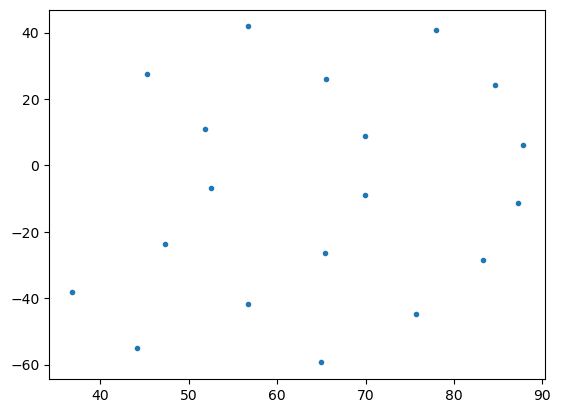

In [28]:
from matplotlib import pyplot as plt
plt.plot(rates.T[0], rates.T[1], '.')

In [35]:
header = wcs_astropy.to_header(relax=True)

In [40]:
header2 =  wcs_astropy.to_header(relax=True)

In [37]:
del(header['PC1_1'])

In [41]:
header.update(header2)

In [46]:
from astropy.io.fits import ImageHDU
import numpy as np

In [47]:
data = np.zeros((3, 10, 10))

In [49]:
f = ImageHDU(data=data)

In [51]:
f.header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                   10                                                  
NAXIS2  =                   10                                                  
NAXIS3  =                    3                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               

AttributeError: 'int' object has no attribute 'comments'

In [ ]:
200000